<a href="https://colab.research.google.com/github/NidhiThakare/AML_Practicals/blob/main/Experiment_4_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving gender_submission.csv to gender_submission.csv


In [ ]:
!pip install scikit-learn matplotlib seaborn pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("Target Classes:", np.unique(y))
X.head()

Dataset Shape: (569, 30)
Target Classes: [0 1]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print(X.info())
print(X.describe())
print("Missing Values:\n", X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (569, 30)


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Reduced Shape:", X_pca.shape)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

PCA Reduced Shape: (569, 2)
Explained Variance Ratio: [0.44272026 0.18971182]


In [ ]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print("LDA Reduced Shape:", X_lda.shape)

LDA Reduced Shape: (569, 1)


In [ ]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
lda_df = pd.DataFrame(X_lda, columns=['LD1'])

print("PCA Features:")
print(pca_df.head())

print("LDA Features:")
print(lda_df.head())

PCA Features:
        PC1        PC2
0  9.192837   1.948583
1  2.387802  -3.768172
2  5.733896  -1.075174
3  7.122953  10.275589
4  3.935302  -1.948072
LDA Features:
        LD1
0 -3.323927
1 -2.319108
2 -3.747425
3 -4.048549
4 -2.281158


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
model_original = LogisticRegression(max_iter=5000)
model_original.fit(X_train, y_train)

y_pred_original = model_original.predict(X_test)

original_acc = accuracy_score(y_test, y_pred_original)

print("Original Data Accuracy:", original_acc)

Original Data Accuracy: 0.9736842105263158


In [ ]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = LogisticRegression(max_iter=5000)
model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

pca_acc = accuracy_score(y_test_pca, y_pred_pca)

print("PCA Accuracy:", pca_acc)

PCA Accuracy: 0.9912280701754386


In [ ]:
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y, test_size=0.2, random_state=42
)

model_lda = LogisticRegression(max_iter=5000)
model_lda.fit(X_train_lda, y_train_lda)

y_pred_lda = model_lda.predict(X_test_lda)

lda_acc = accuracy_score(y_test_lda, y_pred_lda)

print("LDA Accuracy:", lda_acc)

LDA Accuracy: 0.9736842105263158


In [ ]:
print("Classification Accuracy Comparison:")
print("Original Data Accuracy :", original_acc)
print("PCA Reduced Accuracy   :", pca_acc)
print("LDA Reduced Accuracy   :", lda_acc)

Classification Accuracy Comparison:
Original Data Accuracy : 0.9736842105263158
PCA Reduced Accuracy   : 0.9912280701754386
LDA Reduced Accuracy   : 0.9736842105263158


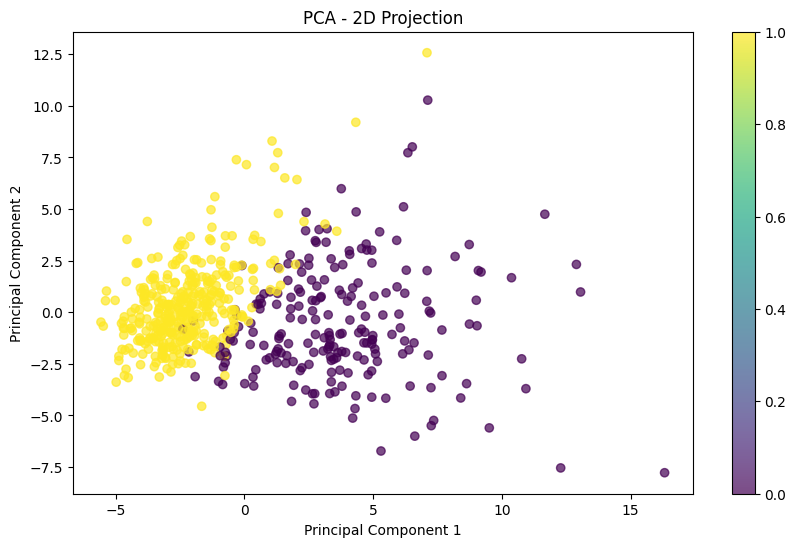

In [ ]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=y,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - 2D Projection")
plt.colorbar(scatter)
plt.show()

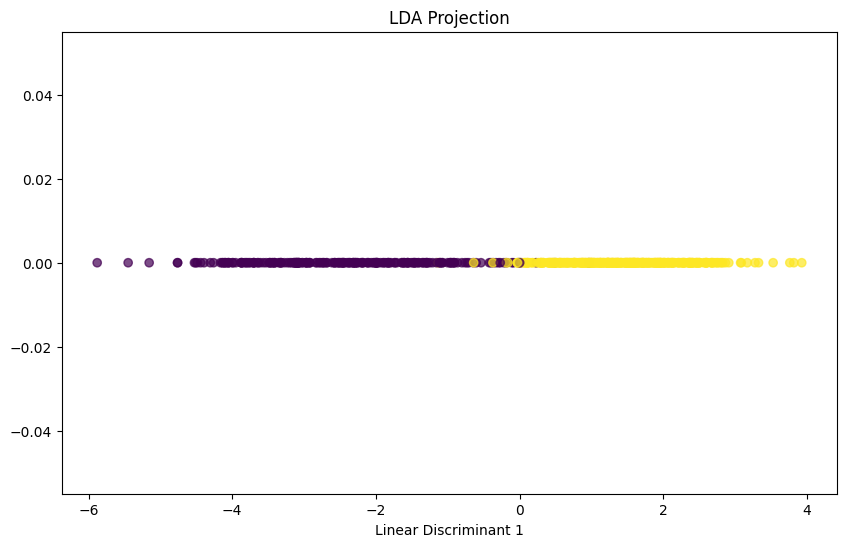

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    X_lda[:,0],
    np.zeros_like(X_lda[:,0]),
    c=y,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel("Linear Discriminant 1")
plt.title("LDA Projection")
plt.show()

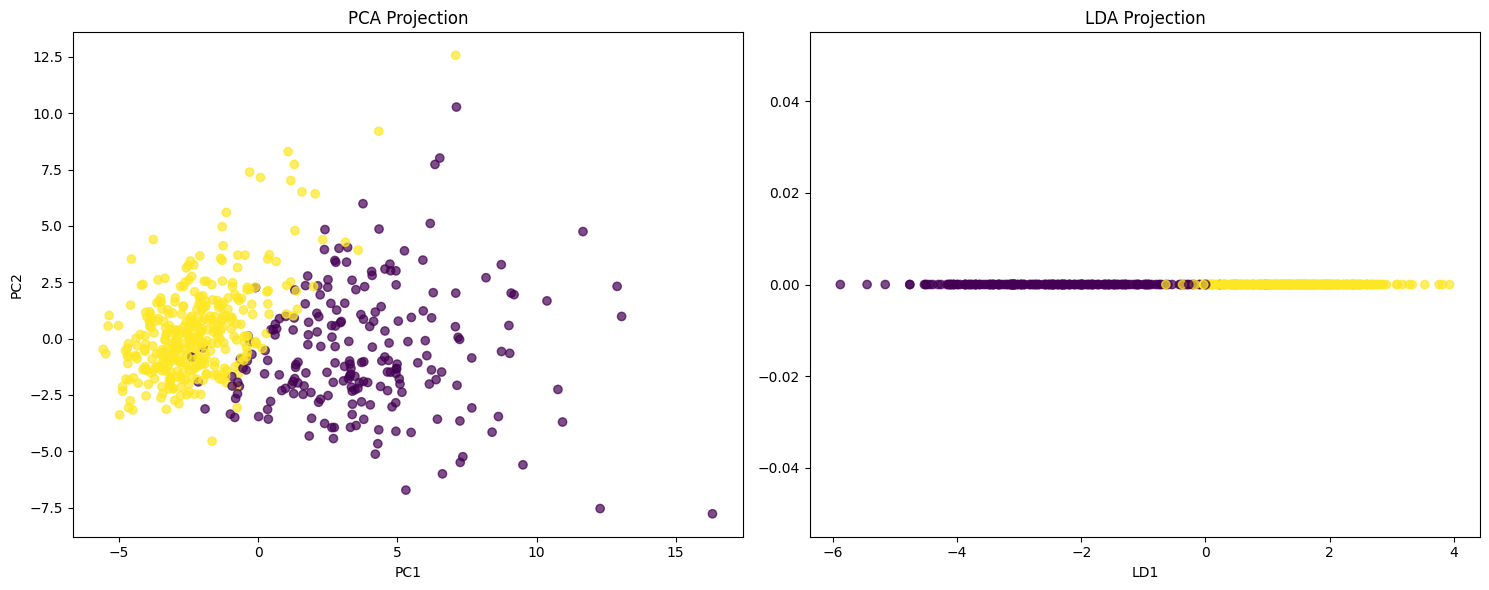

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

# PCA Plot
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# LDA Plot
axes[1].scatter(X_lda[:,0], np.zeros_like(X_lda[:,0]), c=y, cmap='viridis', alpha=0.7)
axes[1].set_title("LDA Projection")
axes[1].set_xlabel("LD1")

plt.tight_layout()
plt.show()